In [1]:
pip install timm

/bin/bash: /home/jia/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchvision
from torchvision import datasets
from torchvision import transforms as T # for simplifying the transforms
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler, random_split, Dataset
from torchvision import models
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
from glob import glob
import cv2
import sys
import timm
import tqdm
from torchvision import datasets
import random
import math
from PIL import Image                                 #Line 3
import torchvision.transforms.functional as TF        #Line 4
from timm.models.layers import to_2tuple
import pandas as pd
from sklearn.metrics import roc_curve, auc, roc_auc_score

/home/jia/anaconda3/envs/xin/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jia/anaconda3/envs/xin/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZNK3c107SymBool10guard_boolEPKcl'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [4]:


# torch.cuda.set_device(0)
# print('__Python VERSION:', sys.version)
# print('__pyTorch VERSION:', torch.__version__)
# print('__CUDA VERSION')
# from subprocess import call
# # call(["nvcc", "--version"]) does not work
# ! nvcc --version
# print('__CUDNN VERSION:', torch.backends.cudnn.version())
# print('__Number CUDA Devices:', torch.cuda.device_count())
# print('__Devices')
# call(["nvidia-smi", "--format=csv", "--query-gpu=index,name,driver_version,memory.total,memory.used,memory.free"])
# print('Active CUDA Device: GPU', torch.cuda.current_device())
# print ('Available devices ', torch.cuda.device_count())
# print ('Current cuda device ', torch.cuda.current_device())

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

Define custom dataset

In [3]:
first_transform = T.Compose([
      T.Resize((224, 224)),
      T.ToTensor(),
  ])


In [4]:
#IMG_PATH = '/content/drive/MyDrive/DL-T Cell Segmentation/June 8th dataset/'

root_tr = '/home/xin/Project/20240620 balanced folder for HvsCLL_Hard only/train'
root_val = '/home/xin/Project/20240620 balanced folder for HvsCLL_Hard only/val'
root_test = '/home/xin/Project/20240620 balanced folder for HvsCLL_Hard only/test'

In [5]:
class patch_dataset(Dataset):
    def __init__(self, root_dir, transform):

        # self
        self.root_dir = root_dir
        self.path_healthy = glob(os.path.join(self.root_dir+ '/0/*.jpg'))
        #self.path_1to30 = glob(os.path.join(self.root_dir+ '/-1/*.jpg'))
        self.path_CLL = glob(os.path.join(self.root_dir+ '/1/*.jpg'))
        self.img_path_list = self.path_healthy  + self.path_CLL
        self.transform = transform
        self.identity = np.array(range(len(self.img_path_list)), dtype=str)

    def __getitem__(self, idx:int):

        img_name = self.img_path_list[idx]
        current_name = img_name.split('/')[-1]
        #print(current_name)
        img = cv2.imread(img_name, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # img = np.transpose(img, (2, 0, 1))

        if self.transform is not None:
          img = self.transform(img)

        if current_name.split('_')[0][0] == 'H':
          label = 0
        
        else:
          label = 1
        sample = {'image': img, 'label':torch.tensor(label, dtype=torch.int8), 'idx': idx, 'image_name': current_name}

        return sample

    def __len__(self):
        return len(self.img_path_list)
      
      #add labels of H or CLL

In [6]:
train_dataset = torchvision.datasets.ImageFolder(root = root_tr, transform = first_transform)
valid_dataset = torchvision.datasets.ImageFolder(root = root_val, transform = first_transform)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=len(train_dataset), num_workers=2)
validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=len(valid_dataset), num_workers=2)
test_dataset = torchvision.datasets.ImageFolder(root = root_test, transform = first_transform)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), num_workers =2)

In [7]:
len(train_dataset)

6509

In [ ]:
# This cell and the next: To find mean and std of (do not need to run everytime, only the first time)
# for i in range(len(trainloader)):
#   data = next(iter(trainloader))
#   print((data[0]).shape)
#   R = torch.mean(data[0]), torch.std(data[0])
#   break
# print(R)

In [ ]:
# for i in range(len(validloader)):
#   data = next(iter(validloader))
#   print((data[0]).shape)
#   bb = data[0].mean(), data[0].std()
#   break
# print(bb)

In [ ]:
# 8

In [7]:
# normalize: Gaussian distribution, if some images are very dim, turn brighter

train_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    #T.RandomRotation((15, 165)), #randomly select a degree between 15 and 165
    # T.RandomErasing(0.2),
    #T.Normalize(0.0815, 0.1352), #(mean, std)
    # T.Normalize(0.0, 0.1),
])


val_transform = T.Compose([
      T.ToPILImage(),
      T.ToTensor(),
      #T.Normalize(0.0819, 0.1356),
      # T.Normalize(0.0, 0.1),
])

test_transform = T.Compose([
      T.ToPILImage(),
      T.ToTensor(),
      #T.Normalize(0.0877, 0.1366),
      # T.Normalize(0.0, 0.1),
])

In [8]:
try_dataset = patch_dataset(root_test, test_transform)
#to visualize using an example

10
HC5M_20231129_1to10_40min_1_03_p7.jpg
(224, 224, 3)
(224, 224, 3)
label tensor(0, dtype=torch.int8)
identity 10


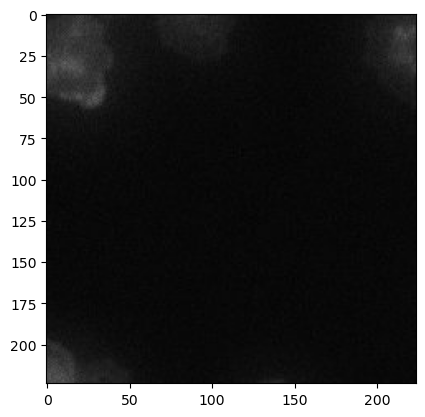

In [9]:
batch = try_dataset.__getitem__(10)
print(batch['idx'])
print(batch['image_name'])
img = batch['image'].numpy()
img = img
img = np.transpose(img, (1,2,0))
print(img.shape)
label = batch['label']
print(img.shape)
plt.imshow(img)
print('label',label)
print('identity', batch['idx'])

In [10]:
def number_of_imgs(path):

  class_num = []
  for value in os.listdir(path):
    total_num = 0
    print(value, "has", len(os.listdir(path + "/" + value)), "imgs")
    total_num = total_num + len(os.listdir(path + "/" + value))
    #total_num = total_num + len(os.listdir(patvalue))
    class_num.append(total_num)
  print('\n')
  return sum(class_num)



ratio = number_of_imgs(root_test) #train dataset

print(ratio)
#print(val_num)

0 has 425 imgs
1 has 390 imgs


815


In [15]:
print(root_tr)

/home/xin/Project/2023 Dec HC5M stiffness classification/20231217 HC5M Image and Mask/splitted dataset/train


In [11]:

HUB_URL = "SharanSMenon/swin-transformer-hub:main" 
MODEL_NAME = "swin_tiny_patch4_window7_224"
# check hubconf for more models.


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#num_classes = 1 
model = torch.hub.load(HUB_URL, MODEL_NAME, pretrained=True) # load from torch hub
#automatically download from HUBURL
# for param in model.parameters():
#     param.requires_grad = True

n_inputs = model.head.in_features
model.head = nn.Sequential(
    nn.Linear(n_inputs, 64),
    nn.ReLU(), #activation, nonlinear--increase generalization
    nn.Dropout(0.2), #20% nodes drop out
    nn.Linear(64, 1), 
    nn.Sigmoid()
)
print(model.head)
# Print the values of the 768 features (weights of the first linear layer)
first_layer_weights = model.head[0].weight.data  # Accessing the weights of the first linear layer
print("Weights of the first layer (768 features):")
print(first_layer_weights)  # Print the weights

# Optionally convert to numpy for easier readability
# Uncomment the following line if you want to see the weights as a NumPy array
# print("Weights as NumPy array:", first_layer_weights.cpu().numpy())

model = model.to(device)


#model.head_in_features: refers to the number of input features that the head part of the model expects to receive

Using cache found in /home/xin/.cache/torch/hub/SharanSMenon_swin-transformer-hub_main
/home/jia/anaconda3/envs/xin/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Sequential(
  (0): Linear(in_features=768, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=1, bias=True)
  (4): Sigmoid()
)
Weights of the first layer (768 features):
tensor([[-4.4687e-03,  2.5364e-02,  7.8465e-04,  ...,  3.4061e-02,
          2.6056e-02, -3.0045e-02],
        [ 3.0252e-02, -2.3771e-02, -2.2005e-02,  ..., -2.5562e-02,
         -4.1443e-03, -9.4633e-03],
        [ 5.4494e-03,  2.4252e-02,  2.2737e-03,  ..., -7.0202e-05,
         -6.7244e-03,  2.5346e-03],
        ...,
        [ 3.0423e-02, -3.5321e-02,  1.2574e-02,  ...,  5.2435e-03,
         -8.3480e-03,  2.0164e-02],
        [-7.2118e-03, -1.3089e-02, -3.3186e-02,  ...,  2.9786e-02,
          3.0802e-03,  2.7326e-02],
        [-2.8131e-02, -2.8071e-02,  2.7645e-02,  ..., -3.2261e-02,
          3.0553e-02,  1.5130e-02]])


In [13]:

# criterion = criterion.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-6)
# lr scheduler
# exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.97)
num_epochs =  100

In [14]:
##IMG_PATH = '/content/drive/MyDrive/DL-T Cell Segmentation/June 8th dataset/'
#root_tr = IMG_PATH + 'test/'
#root_test = IMG_PATH + 'val/'
#root_val = IMG_PATH + 'train/'

bs = 64

train_dataset = patch_dataset(root_dir = root_tr, transform = train_transform)
valid_dataset = patch_dataset(root_dir = root_val, transform = test_transform)
test_dataset = patch_dataset(root_dir = root_test, transform = test_transform)
#to normalize, train--random rotate

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=bs, num_workers=2, shuffle = False)
validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=bs, num_workers=2, shuffle = False)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=bs, num_workers=2, shuffle = False)


train_filenames = glob(os.path.join(root_tr + '/0/*.jpg')) + glob(os.path.join(root_tr + '/1/*.jpg'))
valid_filenames = glob(os.path.join(root_val + '/0/*.jpg')) + glob(os.path.join(root_val + '/1/*.jpg'))
test_filenames = glob(os.path.join(root_test + '/0/*.jpg')) + glob(os.path.join(root_test + '/1/*.jpg'))


In [56]:
print(test_filenames[200])

/home/xin/Project/20240620 balanced folder for HvsCLL_Hard only/test/0/HC5M_20231202_1to10_40min_2_06_p18.jpg


In [15]:
 len(testloader)

13

In [15]:


train_acc = []
train_result = []
valid_acc = []
valid_result = []
bs = bs


#patience = 2


def train_net(patience, number_id):

    trigger_times = 0

    # Start print
    print('--------------------------------')


    print('--------------------------------')

#       IMG_PATH = '/media/sail/HDD14T/BME_Grad_Project/Xin and Shiqi/CV' + str(number_id) + '_multiplied/'


    n_train = len(trainloader)
    n_valid = len(validloader)

    train_accuracy = list()
    train_loss = list()
    valid_loss = list()
    valid_accuracy = list()

    loss_function = nn.BCELoss().to(device)


    # Run the training loop for defined number of epochs
    for epoch in range(0, num_epochs):

        # Print epoch
        print(f'Starting epoch {epoch+1}')
        model.train()
        train_batch_loss = list()
        train_batch_accuracy = list()

        # Iterate over the DataLoader for training data
        for i, batch in enumerate(trainloader):
                train_correct = 0
                train_total = 0

                inputs = batch['image'].to(device)
                labels = batch['label'].float().view(inputs.size(0), 1).to(device)

                outputs = model(inputs)

                # print(outputs.shape)

                # print(outputs)

                pred_binary = (outputs > 0.5)
                # pred_binary = torch.argmax(outputs, dim = 1)
                # outputs = torch.max()

                # Compute loss
                loss = loss_function(outputs, labels)

                train_correct = train_correct + (pred_binary == labels).sum().item()
                train_total = train_total + labels.size(0)

                # Zero the gradients
                optimizer.zero_grad()

                # Perform backward pass
                loss.backward()

                # Perform optimization
                optimizer.step()
                # exp_lr_scheduler.step()

              # Print statistics
                batch_loss = loss.item()
                train_batch_loss.append(batch_loss)
                train_batch_accuracy.append(train_correct/train_total)

        epoch_train_loss = np.array(train_batch_loss).mean()
        train_loss.append(epoch_train_loss)
        epoch_train_accuracy = np.array(train_batch_accuracy).mean()
        train_accuracy.append(epoch_train_accuracy)

        model.eval()
        epoch_valid_loss = 0
        valid_batch_loss = list()
        valid_batch_accuracy = list()

        with torch.set_grad_enabled(False):

            # Iterate over the test data and generate predictions
                for i, batch in enumerate(validloader):
                    valid_correct = 0
                    valid_total = 0

                    inputs = batch['image'].to(device)
                    labels = batch['label'].float().view(inputs.size(0),1).to(device)


                    outputs = model(inputs)


                    pred_binary = (outputs > 0.5)

                    loss = loss_function(outputs, labels)
                    # print('loss', loss)
                    valid_correct = valid_correct + (pred_binary == labels).sum().item()
                    valid_total = valid_total + labels.size(0)

                    batch_loss = loss.item()
                    valid_batch_loss.append(batch_loss)

                    valid_batch_accuracy.append(valid_correct/valid_total)

            

                epoch_valid_loss = np.array(valid_batch_loss).mean()
                valid_loss.append(epoch_valid_loss)
                epoch_valid_accuracy = np.array(valid_batch_accuracy).mean()
                valid_accuracy.append(epoch_valid_accuracy)
                
        save_dict = {
           'model_state_dict': model.state_dict(),
           'train_loss': train_loss,
           'train_accuracy': train_accuracy,
           'valid_loss': valid_loss,
           'valid_r2': valid_accuracy
        }

        print(f'EPOCH {epoch + 1}/{num_epochs} - Training Loss: {epoch_train_loss} - Training Accuracy: {epoch_train_accuracy} - Validation Loss: {epoch_valid_loss} - Validation Accuracy: {epoch_valid_accuracy}')
        torch.save(model.state_dict(), f'/home/xin/Project/20240620 Hard only_HvsCLL_full dataset_saved model/epoch_{epoch+1:03}.pth')

    print('--------------------------------')

    return train_loss, train_accuracy, valid_loss, valid_accuracy, train_filenames, valid_filenames

In [19]:
number_id = 2
avg_train_loss, avg_train_accuracy, avg_valid_loss, avg_valid_accuracy, train_filenames, valid_filenames = train_net(3, number_id)

--------------------------------
--------------------------------
Starting epoch 1
EPOCH 1/100 - Training Loss: 0.6844052789258022 - Training Accuracy: 0.5653526688453159 - Validation Loss: 0.6577429863122793 - Validation Accuracy: 0.6831196581196581
Starting epoch 2
EPOCH 2/100 - Training Loss: 0.6307474176088969 - Training Accuracy: 0.6805078976034858 - Validation Loss: 0.5844317812186021 - Validation Accuracy: 0.6970886752136752
Starting epoch 3
EPOCH 3/100 - Training Loss: 0.5797504882017771 - Training Accuracy: 0.7105562363834422 - Validation Loss: 0.5452133004481976 - Validation Accuracy: 0.718162393162393
Starting epoch 4
EPOCH 4/100 - Training Loss: 0.5609597993247649 - Training Accuracy: 0.7237540849673203 - Validation Loss: 0.5253935547975394 - Validation Accuracy: 0.7430288461538462
Starting epoch 5
EPOCH 5/100 - Training Loss: 0.5462552557388941 - Training Accuracy: 0.7309708605664488 - Validation Loss: 0.5181135879113123 - Validation Accuracy: 0.7440972222222222
Starting e

In [18]:
# best_epoch = (np.argmin(avg_valid_loss) + 1)
best_epoch = (np.argmax(avg_valid_accuracy) + 1)
print(best_epoch)
plt.figure(figsize = [12, 6])
plt.subplot(121)
plt.plot(avg_train_loss, label="train_loss")
plt.plot(avg_valid_loss, label="valid_loss")
plt.title('loss')
plt.legend()

plt.subplot(122)
plt.plot(avg_train_accuracy, label="train_acc")
plt.plot(avg_valid_accuracy, label="valid_acc")
plt.title('accuracy')
plt.legend()

NameError: name 'avg_valid_accuracy' is not defined

In [16]:
# best_epoch = 39
# best_epoch = 74
best_epoch = 84
state_dict = torch.load(f'/home/xin/Project/20240620 Hard only_HvsCLL_full dataset_saved model/epoch_{best_epoch:03}.pth')

model.load_state_dict(state_dict)
model.cuda()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (layers): ModuleList(
    (0): BasicLayer(
      dim=96, input_resolution=(56, 56), depth=2
      (blocks): ModuleList(
        (0): SwinTransformerBlock(
          dim=96, input_resolution=(56, 56), num_heads=3, window_size=7, shift_size=0, mlp_ratio=4.0
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            dim=96, window_size=(7, 7), num_heads=3
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path): Identity()
          (norm2): LayerNo

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
def plot_roc_curve(true_y, y_prob):
      fpr, tpr, thresholds = roc_curve(true_y, y_prob)
      plt.figure()
      plt.plot(fpr, tpr)
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')


In [18]:
import re
def image_accuracy(result, ratio, type):
  # pred = pred.numpy()
  # labels = labels.numpy()
    idx = result[:,2]
#     print(idx[0:10])
#     label = result[:,0]
    pred = result[:,1]
    image_list = list()
#     num_imgs = len(label)

    if type == 'train':
        filenames = train_filenames
    elif type == 'val':
        filenames = valid_filenames
    elif type == 'test':
        filenames = test_filenames

#     print(len(pred))

    for i in (idx):
        i = int(i)
#         print(filenames[0:5])
        curr_identity = filenames[i].split('/')[-1]
#         print(curr_identity)
        image_name = re.sub(curr_identity.split('_')[-1], '', curr_identity)
         #print(image_name)
        image_list.append(image_name)


    image_list = np.asarray(image_list)
    num_imgs = len(np.unique(image_list))
    true_label = 0
    pred_label = 0
    image_pred_label = np.zeros((num_imgs))
    image_true_label = np.zeros((num_imgs))
    image_pred_rate = np.zeros((num_imgs))



    for i in range(num_imgs):
        current_image_name = np.unique(image_list)[i]
        patch_id = np.where(image_list == current_image_name)
        patch_id = np.array(patch_id)

        positive_ratio = np.sum(pred[patch_id] == 1)/patch_id.shape[1]
        image_pred_rate[i] = positive_ratio

        if positive_ratio > ratio:
            pred_label = 1
        else:
            pred_label = 0

        print(current_image_name, positive_ratio)
        if current_image_name.split('_')[0][0] == 'C':
            true_label = 1

        else:
            true_label = 0

        image_true_label[i] = true_label
        image_pred_label[i] = pred_label

    print('img', image_pred_label)
    print('labels', image_true_label)
    print(np.sum(image_pred_label == image_true_label))
    accuracy = np.sum(image_true_label == image_pred_label)/len(np.unique(image_list))

    return accuracy, image_pred_label, image_true_label, image_pred_rate

In [19]:
pip install pandas xlsxwriter

/bin/bash: /home/jia/anaconda3/envs/xin/lib/python3.10/site-packages/cv2/../../../../lib/libtinfo.so.6: no version information available (required by /bin/bash)
Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd  # Import pandas for saving features to a spreadsheet

# Initialize extracted_features as a list
#extracted_features = []

def get_features_hook(module, input, output):
    global extracted_features
    extracted_features.append(output.detach().cpu().numpy())  



def test_net(net, test_dataloader, ratio, num, data_type ):
    global extracted_features
    
    # Clear extracted_features before each test
    extracted_features = []
    image_list=[]
    


    net.eval()
    
    #register the hook at avgpool
    hook_handle = net.avgpool.register_forward_hook(get_features_hook)

    n_test = len(test_dataloader)
    batch_test_accuracy = list()
    batch_test_loss = list()
    result = np.zeros((num, 4))

    loss_function = nn.BCELoss().to(device)

    # This part is almost the same as the validation loop in `train_net` function.
    # The difference is that we will calculate the accuracy and confusion matrix per each batch and save the predicted images.
    with torch.no_grad():
        for i, batch in enumerate(test_dataloader):

            # Load a batch and pass it to the GPU
            test_correct = 0
            imgs = batch['image'].to(device)
            labels = batch['label'].float().view(imgs.size(0),1).to(device)
            idx = batch['idx'].int().view(imgs.size(0),1).to(device)
            
            image_name=batch['image_name']
    
            #curr_identity = test_filenames[batch['idx']].split('/')[-1]
#        
            #image_name = re.sub(curr_identity.split('_')[-1], '', curr_identity)
         #print(image_name)
            image_list += image_name
            
            
            
            y_pred = net(imgs)
            

                
        
            pred_binary = (y_pred > 0.5).to(device)

            loss = loss_function(y_pred, labels).item()
            batch_test_loss.append(loss)

            test_correct = test_correct + (pred_binary == labels).sum().item()
            test_total = labels.size(0)
            batch_test_accuracy.append(test_correct/test_total)

            batch_result = np.concatenate((labels.cpu().numpy(), pred_binary.cpu().numpy(),idx.cpu().numpy(), y_pred.cpu()), axis=1)

            bs_num = bs

            if i == len(test_dataloader)-1:
                result[(i)*bs_num:,:] = batch_result
            else:
                result[(i)*bs_num:(i)*bs_num + bs_num,:] = batch_result
                
            #if extracted_features[-1].shape[0] != bs_num:
                #print(f"Mismatch in batch {i}: extracted features have {extracted_features[-1].shape[0]} rows, but batch has {bs_num} images.")
            
            

        test_loss = np.array(batch_test_loss).mean()
        test_accuracy = np.array(batch_test_accuracy).mean()


        dir_type = data_type
        test_img_accuracy, img_pred, img_true, img_pred_rate = image_accuracy(result, ratio, dir_type)

        print(f'Test Loss: {test_loss} - Patch Level Accuracy: {test_accuracy} - Image Level Accuracy: {test_img_accuracy}')
 
 
  
    all_features = np.concatenate(extracted_features, axis=0)
    print(len(all_features))
    print(len(image_list))
    
        # Squeeze if needed
    
    if all_features.ndim == 3:
        all_features = np.squeeze(all_features)
    
    
    # Save features to a DataFrame
    df_features = pd.DataFrame(all_features, index=image_list)
    df_features.to_excel('/home/xin/Project/20241001_extracted_768_features_new.xlsx', index=image_list)  # Save to Excel

    hook_handle.remove()



    return result, img_pred, img_true, img_pred_rate

In [21]:
number_id = 2
# # bs = 256
# IMG_PATH = '/media/sail/HDD14T/BME_Grad_Project/Xin and Shiqi/CV' + str(number_id) + '_multiplied/'
# root_val = IMG_PATH + 'test/'
test_dataset = patch_dataset(root_dir = root_test, transform = test_transform)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, num_workers=0, shuffle=False)

# testloader = torch.utils.data.DataLoader(test_dataset, batch_size=128, num_workers=0)

In [37]:
num_imgs = number_of_imgs(root_test)
print(num_imgs)
print(root_test)

0 has 425 imgs
1 has 390 imgs


815
/home/xin/Project/20240620 balanced folder for HvsCLL_Hard only/test


In [22]:
result, img_pred, img_true, img_pred_rate = test_net(model, testloader, ratio = 0.5, num = number_of_imgs(root_test) , data_type = 'test')


0 has 425 imgs
1 has 390 imgs


CLLAlKn_20240217_1to10_40min_1_01_ 1.0
CLLAlKn_20240217_1to10_40min_1_04_ 1.0
CLLAlKn_20240217_1to10_40min_1_05_ 1.0
CLLAlKn_20240217_1to10_40min_1_06_ 1.0
CLLAlKn_20240217_1to10_40min_1_07_ 0.0
CLLAlKn_20240217_1to10_40min_1_08_ 0.5
CLLAlKn_20240217_1to10_40min_1_09_ 1.0
CLLAlKn_20240217_1to10_40min_1_10_ 1.0
CLLAlKn_20240221_1to10_40min_1_02_ 1.0
CLLAlKn_20240221_1to10_40min_1_03_ 1.0
CLLAlKn_20240221_1to10_40min_1_04_ 1.0
CLLAlKn_20240221_1to10_40min_1_05_ 1.0
CLLAlKn_20240221_1to10_40min_1_06_ 1.0
CLLAlKn_20240221_1to10_40min_1_07_ 1.0
CLLAlKn_20240221_1to10_40min_1_08_ 1.0
CLLAlKn_20240221_1to10_40min_1_09_ 1.0
CLLAlKn_20240221_1to10_40min_2_02_ 1.0
CLLAlKn_20240221_1to10_40min_2_03_ 1.0
CLLAlKn_20240221_1to10_40min_2_04_ 1.0
CLLAlKn_20240221_1to10_40min_2_05_ 1.0
CLLAlKn_20240221_1to10_40min_2_07_ 1.0
CLLAlKn_20240221_1to10_40min_2_09_ 1.0
CLLBaMu_20240208_1to10_40min_1_05_ 0.6666666666666666
CLLBaMu_20240208_1to10_40min_1_06_ 1.0
CLLBaMu_20240208_

In [41]:
len(test_filenames)

815

In [38]:
def compute_image_confusion_matrix(img_true, img_pred):
    img_cm = confusion_matrix(img_true, img_pred)
    return img_cm

# Assuming you have img_true_label and img_pred_label from your function call
img_cm = compute_image_confusion_matrix(img_true, img_pred)
print("Image-level Confusion Matrix:")
print(img_cm)

Image-level Confusion Matrix:
[[145  11]
 [ 43 183]]


In [39]:
def compute_sensitivity_specificity(cm):
    # Assuming binary classification: cm = [[TN, FP], [FN, TP]]
    TN, FP, FN, TP = cm.ravel()

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    
    return sensitivity, specificity


# Calculate sensitivity and specificity
sensitivity, specificity = compute_sensitivity_specificity(img_cm)
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")

Sensitivity: 0.8097345132743363
Specificity: 0.9294871794871795


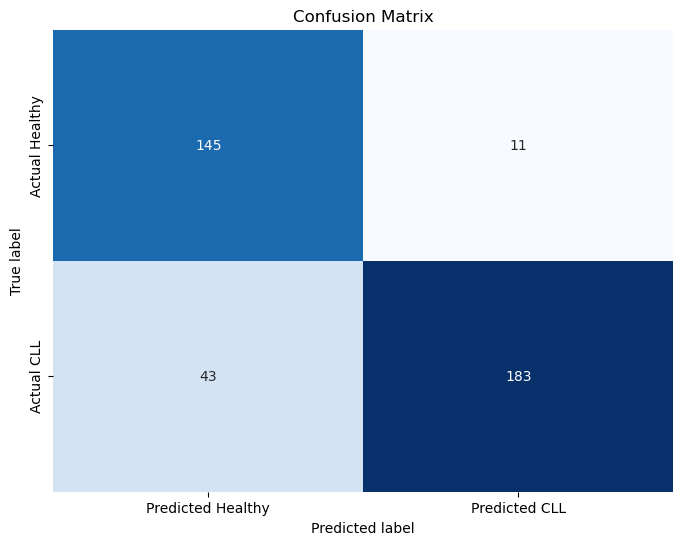

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define the patch-level confusion matrix data
conf_matrix_data = np.array([[145, 11],
                             [43, 183]])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_data, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Healthy', 'Predicted CLL'],
            yticklabels=['Actual Healthy', 'Actual CLL'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [33]:
val_dataset = patch_dataset(root_dir = root_val, transform = test_transform)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=bs, num_workers=0)

In [34]:
print(root_val)

/home/xin/Project/2023 Dec HC5M stiffness classification/20231217 HC5M Image and Mask/updated 2-category splitted dataset/val


In [35]:
num_imgs = number_of_imgs(root_val)
print(num_imgs)
# print(len(trloader))

0 has 505 imgs
1 has 576 imgs


1081


In [40]:
pat_result_val, img_pred_val, img_true_val, img_pred_rate_val = test_net(model, validloader, ratio = 0.5, num=number_of_imgs(root_val),  data_type = 'val')

0 has 425 imgs
1 has 388 imgs


CLLAlKn_20240217_1to10_40min_1_01_ 1.0
CLLAlKn_20240217_1to10_40min_1_02_ 1.0
CLLAlKn_20240217_1to10_40min_1_04_ 0.0
CLLAlKn_20240217_1to10_40min_1_05_ 1.0
CLLAlKn_20240217_1to10_40min_1_06_ 0.0
CLLAlKn_20240217_1to10_40min_1_07_ 0.5
CLLAlKn_20240217_1to10_40min_1_08_ 0.0
CLLAlKn_20240217_1to10_40min_1_09_ 1.0
CLLAlKn_20240217_1to10_40min_1_10_ 1.0
CLLAlKn_20240221_1to10_40min_1_01_ 1.0
CLLAlKn_20240221_1to10_40min_1_03_ 1.0
CLLAlKn_20240221_1to10_40min_1_07_ 1.0
CLLAlKn_20240221_1to10_40min_1_08_ 1.0
CLLAlKn_20240221_1to10_40min_1_09_ 1.0
CLLAlKn_20240221_1to10_40min_2_01_ 1.0
CLLAlKn_20240221_1to10_40min_2_04_ 1.0
CLLAlKn_20240221_1to10_40min_2_05_ 1.0
CLLAlKn_20240221_1to10_40min_2_06_ 1.0
CLLAlKn_20240221_1to10_40min_2_08_ 1.0
CLLAlKn_20240221_1to10_40min_2_09_ 1.0
CLLAlKn_20240221_1to10_40min_2_10_ 1.0
CLLBaMu_20240208_1to10_40min_1_01_ 1.0
CLLBaMu_20240208_1to10_40min_1_04_ 1.0
CLLBaMu_20240208_1to10_40min_1_05_ 0.5
CLLBaMu_20240208_1to10_40min_1_0

In [32]:
pat_result_test, img_pred_test, img_true_test, img_pred_rate_test = test_net(model, testloader, ratio = 0.5, num = number_of_imgs(root_test) , data_type = 'test')

0 has 425 imgs
1 has 390 imgs


CLLAlKn_20240217_1to10_40min_1_01_ 1.0
CLLAlKn_20240217_1to10_40min_1_04_ 1.0
CLLAlKn_20240217_1to10_40min_1_05_ 1.0
CLLAlKn_20240217_1to10_40min_1_06_ 1.0
CLLAlKn_20240217_1to10_40min_1_07_ 0.0
CLLAlKn_20240217_1to10_40min_1_08_ 0.5
CLLAlKn_20240217_1to10_40min_1_09_ 1.0
CLLAlKn_20240217_1to10_40min_1_10_ 1.0
CLLAlKn_20240221_1to10_40min_1_02_ 1.0
CLLAlKn_20240221_1to10_40min_1_03_ 1.0
CLLAlKn_20240221_1to10_40min_1_04_ 1.0
CLLAlKn_20240221_1to10_40min_1_05_ 1.0
CLLAlKn_20240221_1to10_40min_1_06_ 1.0
CLLAlKn_20240221_1to10_40min_1_07_ 1.0
CLLAlKn_20240221_1to10_40min_1_08_ 1.0
CLLAlKn_20240221_1to10_40min_1_09_ 1.0
CLLAlKn_20240221_1to10_40min_2_02_ 1.0
CLLAlKn_20240221_1to10_40min_2_03_ 1.0
CLLAlKn_20240221_1to10_40min_2_04_ 1.0
CLLAlKn_20240221_1to10_40min_2_05_ 1.0
CLLAlKn_20240221_1to10_40min_2_07_ 1.0
CLLAlKn_20240221_1to10_40min_2_09_ 1.0
CLLBaMu_20240208_1to10_40min_1_05_ 0.6666666666666666
CLLBaMu_20240208_1to10_40min_1_06_ 1.0
CLLBaMu_20240208_

In [41]:
tr_dataset = patch_dataset(root_dir = root_tr, transform = test_transform)
trloader = torch.utils.data.DataLoader(tr_dataset, batch_size=bs, num_workers=0)

In [38]:
print(root_tr)

/home/xin/Project/2023 Dec HC5M stiffness classification/20231217 HC5M Image and Mask/updated 2-category splitted dataset/train


In [42]:
pat_result_tr, img_pred_tr, img_true_tr, img_pred_rate_tr = test_net(model, trainloader, ratio = 0.5, num=number_of_imgs(root_tr),  data_type = 'train')

#pat_result_val, img_pred_val, img_true_val, img_pred_rate_val = test_net(model, valloader, ratio = 0.5, num=number_of_imgs(root_val),  data_type = 'val')

0 has 3400 imgs
1 has 3109 imgs




CLLAlKn_20240217_1to10_40min_1_01_ 1.0
CLLAlKn_20240217_1to10_40min_1_02_ 0.8333333333333334
CLLAlKn_20240217_1to10_40min_1_03_ 1.0
CLLAlKn_20240217_1to10_40min_1_04_ 1.0
CLLAlKn_20240217_1to10_40min_1_05_ 0.8888888888888888
CLLAlKn_20240217_1to10_40min_1_06_ 0.875
CLLAlKn_20240217_1to10_40min_1_07_ 0.8181818181818182
CLLAlKn_20240217_1to10_40min_1_08_ 1.0
CLLAlKn_20240217_1to10_40min_1_09_ 1.0
CLLAlKn_20240217_1to10_40min_1_10_ 0.9333333333333333
CLLAlKn_20240221_1to10_40min_1_01_ 1.0
CLLAlKn_20240221_1to10_40min_1_02_ 1.0
CLLAlKn_20240221_1to10_40min_1_03_ 1.0
CLLAlKn_20240221_1to10_40min_1_04_ 1.0
CLLAlKn_20240221_1to10_40min_1_05_ 1.0
CLLAlKn_20240221_1to10_40min_1_06_ 1.0
CLLAlKn_20240221_1to10_40min_1_07_ 1.0
CLLAlKn_20240221_1to10_40min_1_08_ 1.0
CLLAlKn_20240221_1to10_40min_1_09_ 1.0
CLLAlKn_20240221_1to10_40min_1_10_ 1.0
CLLAlKn_20240221_1to10_40min_2_01_ 1.0
CLLAlKn_20240221_1to10_40min_2_02_ 1.0
CLLAlKn_20240221_1to10_40min_2_03_ 1.0
CLLAlKn_20240221_1to10_40min_2_04_ 1.0
CL

In [43]:
pat_pred_tr = pat_result_tr[:,3]
pat_true_tr = pat_result_tr[:,0]
print(pat_pred_tr.shape)

(6509,)


In [44]:
pat_pred_val = pat_result_val[:,3]
pat_true_val = pat_result_val[:,0]
print(pat_pred_val.shape)

(813,)


In [45]:
pat_pred_test = pat_result_test[:,3]
pat_true_test = pat_result_test[:,0]
print(pat_pred_test.shape)

(815,)


In [34]:
def ROCanalysis(pred, true):

    fpr, tpr, thresholds = roc_curve(true, pred)
#     print(fpr[:10],tpr[:10],thresholds[:10])
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label="AUC="+str(roc_auc_score(true, pred)))
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.legend(loc=4)
    plt.show()
    print("Area under the ROC cuve : %f" % roc_auc)

    i = np.arange(len(tpr))
    roc = pd.DataFrame({'tf' :pd.Series(tpr-(1-fpr), index=i), 'threshold' : pd.Series(thresholds, index = i)})
    roc_t = roc.iloc[(roc.tf-0).abs().argsort()[:1]]

    print("Optimal cutoff point is : %f" % roc_t['threshold'])



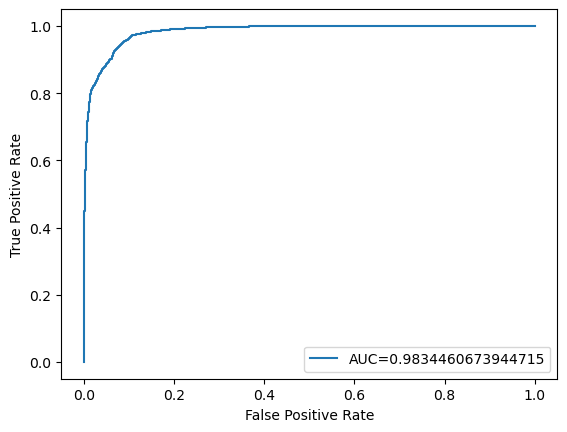

Area under the ROC cuve : 0.983446
Optimal cutoff point is : 0.519433


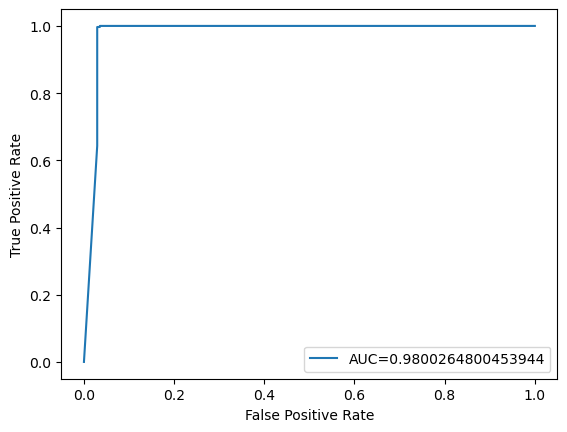

Area under the ROC cuve : 0.980026
Optimal cutoff point is : 0.636364


In [46]:
ROCanalysis(pat_pred_tr, pat_true_tr)
ROCanalysis(img_pred_rate_tr, img_true_tr)

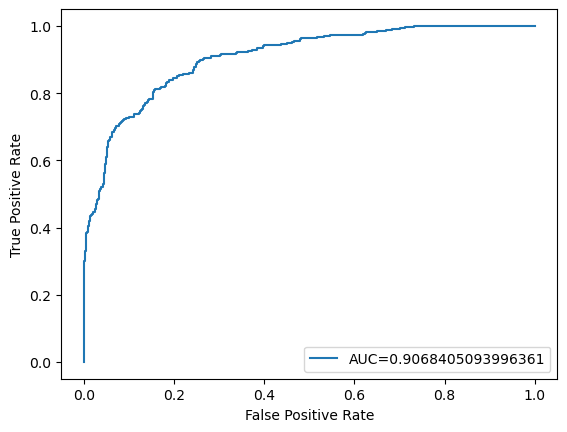

Area under the ROC cuve : 0.906841
Optimal cutoff point is : 0.468237


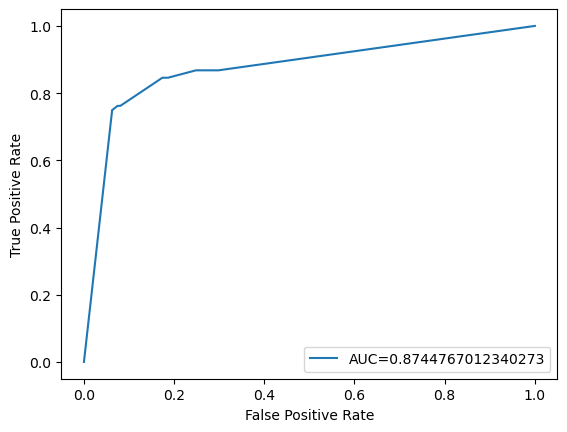

Area under the ROC cuve : 0.874477
Optimal cutoff point is : 0.500000


In [47]:
ROCanalysis(pat_pred_val, pat_true_val)
ROCanalysis(img_pred_rate_val, img_true_val)

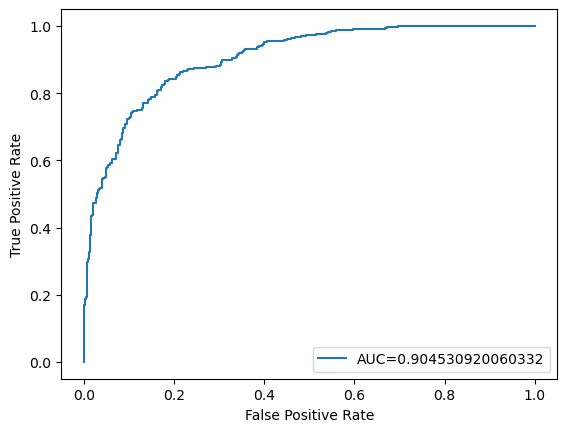

Area under the ROC cuve : 0.904531
Optimal cutoff point is : 0.478326


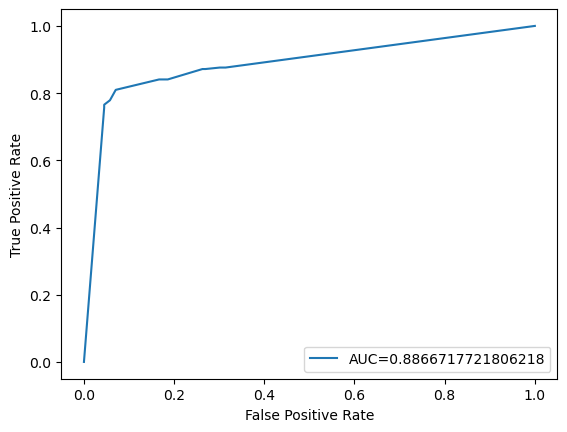

Area under the ROC cuve : 0.886672
Optimal cutoff point is : 0.500000


In [36]:
ROCanalysis(pat_pred_test, pat_true_test)
ROCanalysis(img_pred_rate_test, img_true_test)